### See dot product as similarity

In [9]:
import numpy as np

# Customer purchase history
# 1 = bought, 0 = didn't buy
# [shirt, jeans, shoes, hat, watch]

customer_a = np.array([1, 0, 1, 0, 1])
customer_b = np.array([1, 1, 1, 0, 0])  # similar to a
customer_c = np.array([0, 0, 0, 1, 1])  # different from a



## dot product
check_similarity_a_b = np.dot(customer_a,customer_b)
print(check_similarity_a_b) ## 2 similar as its high and +ive

check_similarity_b_c = np.dot(customer_b,customer_c)
print(check_similarity_b_c) ## 0 completely differ


#### cosine similarity
##  Normalizes the dot product so vector length doesn't affect similarity
customer_d = np.array([1,1,0,0,0]) # only baught jeans and shirt

def cosine_similarity(x,y):
    result = np.dot(x,y) / (np.linalg.norm(x) * np.linalg.norm(y))
    return result

check_similarity_a_d = cosine_similarity(customer_a,customer_d)

print(check_similarity_a_d) # 0.40

check_similarity_a_b = cosine_similarity(customer_a,customer_b)

print(check_similarity_a_b) ## 0.66 more similar

# Range: 0 to 1 — closer to 1 = more similar

# THIS is how KNN finds nearest neighbours
# THIS is how recommendation engines work
# THIS is how search engines rank results


2
0
0.40824829046386296
0.6666666666666667


## PART 2 — Decision Trees Deep Dive

 ### How Decision Trees actually think

In [19]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split


data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train small tree so we can READ it
dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_small.fit(X_train, y_train)
# PRINT THE ACTUAL RULES IT LEARNED
print("=== Rules the Decision Tree Learned ===\n")
rules = export_text(dt_small,
                    feature_names=list(data.feature_names))
print(rules)
# You will see something like:
# |--- petal length (cm) <= 2.45
# |   |--- class: setosa
# |--- petal length (cm) > 2.45
# |   |--- petal width (cm) <= 1.75
# |   |   |--- class: versicolor
# |   |--- petal width (cm) > 1.75
# |   |   |--- class: virginica

# The model found these rules ITSELF from data
# No one told it "check petal length first

=== Rules the Decision Tree Learned ===

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



### The overfitting experiment:

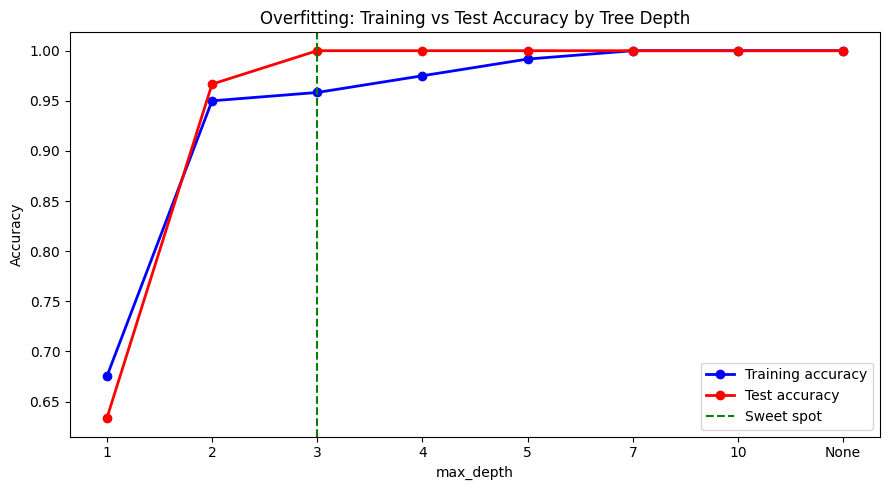


=== Detailed Results ===
depth=1     train=0.68 test=0.63 gap=0.04 ✅ OK
depth=2     train=0.95 test=0.97 gap=-0.02 ✅ OK
depth=3     train=0.96 test=1.00 gap=-0.04 ✅ OK
depth=4     train=0.97 test=1.00 gap=-0.03 ✅ OK
depth=5     train=0.99 test=1.00 gap=-0.01 ✅ OK
depth=7     train=1.00 test=1.00 gap=0.00 ✅ OK
depth=10    train=1.00 test=1.00 gap=0.00 ✅ OK
depth=None  train=1.00 test=1.00 gap=0.00 ✅ OK


In [20]:
import matplotlib.pyplot as plt

# KEY CONCEPT: max_depth controls complexity
# Too deep = memorises training data = overfits
# Too shallow = too simple = underfits

depths = [1, 2, 3, 4, 5, 7, 10, None]
train_scores = []
test_scores  = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Plot
depth_labels = [str(d) if d else 'None' for d in depths]
x = range(len(depths))

plt.figure(figsize=(9, 5))
plt.plot(x, train_scores, 'b-o', label='Training accuracy', linewidth=2)
plt.plot(x, test_scores,  'r-o', label='Test accuracy',     linewidth=2)
plt.xticks(x, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting: Training vs Test Accuracy by Tree Depth')
plt.legend()
plt.axvline(x=2, color='green', linestyle='--',
            label='Sweet spot')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Detailed Results ===")
for depth, tr, te in zip(depth_labels, train_scores, test_scores):
    gap    = tr - te
    status = '⚠️ OVERFIT' if gap > 0.05 else '✅ OK'
    print(f"depth={depth:5} train={tr:.2f} test={te:.2f} "
          f"gap={gap:.2f} {status}")

### Visualise what the tree actually splits:

In [26]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [27]:
X[:,2:4]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

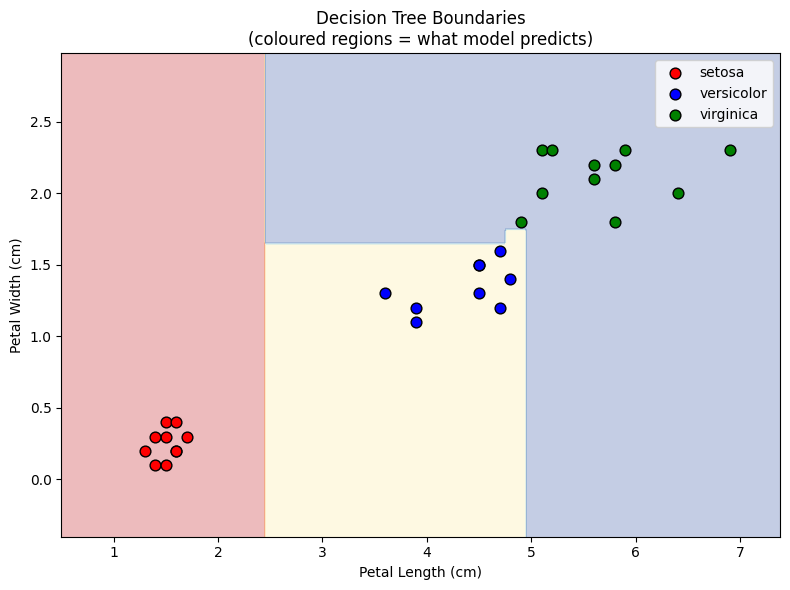

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Plot decision boundaries using 2 features
# so we can visualise in 2D

# Use only petal length and petal width (most important)
X_2d       = X[:, 2:4]   # petal length, petal width
X_train_2d = X_train[:, 2:4]
X_test_2d  = X_test[:, 2:4]

dt_2d = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_2d.fit(X_train_2d, y_train)

# Create mesh grid
x_min, x_max = X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5
y_min, y_max = X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
colors = ['red', 'blue', 'green']
for i, (color, name) in enumerate(zip(colors, data.target_names)):
    mask = y_test == i
    plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                c=color, label=name, edgecolors='black', s=60)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Decision Tree Boundaries\n(coloured regions = what model predicts)')
plt.legend()
plt.tight_layout()
plt.show()

# The rectangular boundaries = the if/else rules you saw earlier
# This is literally the tree drawn as regions on a chart

## PART 3 — KNN Deep Dive 

### How KNN works step by step:

In [31]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# KNN LOGIC (write this in your notebook):
# 1. Take a new data point
# 2. Calculate distance to ALL training points
# 3. Find K closest points (nearest neighbours)
# 4. Take a vote — majority class wins
# 5. That is your prediction

print("""
KNN Example:
============
New patient: [age=45, bp=130]
Training data has 100 patients (50 healthy, 50 sick)

K=3: Find 3 nearest patients
     - Patient A: sick  (distance=2.1)
     - Patient B: sick  (distance=3.4)
     - Patient C: healthy (distance=4.0)

Vote: 2 sick, 1 healthy
Prediction: SICK

That's all KNN does. No training. Just remembering.
""")


KNN Example:
New patient: [age=45, bp=130]
Training data has 100 patients (50 healthy, 50 sick)

K=3: Find 3 nearest patients
     - Patient A: sick  (distance=2.1)
     - Patient B: sick  (distance=3.4)
     - Patient C: healthy (distance=4.0)

Vote: 2 sick, 1 healthy
Prediction: SICK

That's all KNN does. No training. Just remembering.



### KNN needs scaling (important lesson):

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== Why KNN MUST be scaled ===\n")
print("Feature ranges BEFORE scaling:")
import pandas as pd
df = pd.DataFrame(X, columns=data.feature_names)

=== Why KNN MUST be scaled ===

Feature ranges BEFORE scaling:


In [44]:
print(df.describe().loc[['min','max']].round(2))


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min                4.3               2.0                1.0               0.1
max                7.9               4.4                6.9               2.5



Problem: sepal length goes 4.3 to 7.9
         petal width  goes 0.1 to 2.5
Distance will be dominated by sepal length!
Petal width barely matters -- even if it's more important

KNN WITHOUT scaling: 100.0%


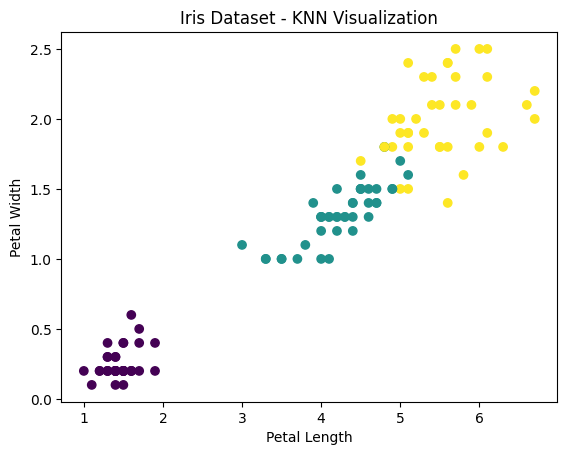

In [53]:
print("\nProblem: sepal length goes 4.3 to 7.9") ##long
print("         petal width  goes 0.1 to 2.5") # short
print("Distance will be dominated by sepal length!")
print("Petal width barely matters -- even if it's more important\n")
# WITHOUT scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
print(f"KNN WITHOUT scaling: {knn_raw.score(X_test, y_test):.1%}")
import matplotlib.pyplot as plt
# plot data
import matplotlib.pyplot as plt

plt.scatter(
    X_train[:,2],   # petal length
    X_train[:,3],   # petal width
    c=y_train       # color by class
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset - KNN Visualization")

plt.show()

KNN WITH scaling:    100.0%

Always scale before using KNN!


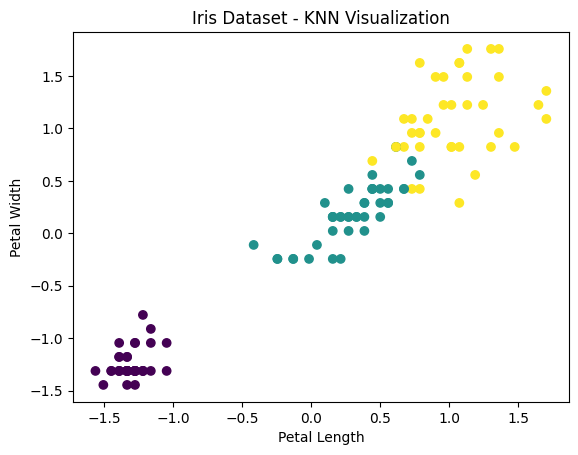

In [57]:
# WITH scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only!
X_test_s  = scaler.transform(X_test)       # transform test with same scaler

knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_s, y_train)
print(f"KNN WITH scaling:    {knn_scaled.score(X_test_s, y_test):.1%}")
print("\nAlways scale before using KNN!")
import matplotlib.pyplot as plt
# plot data
import matplotlib.pyplot as plt

plt.scatter(
    X_train_s[:,2],   # petal length
    X_train_s[:,3],   # petal width
    c=y_train       # color by class
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset - KNN Visualization")

plt.show()

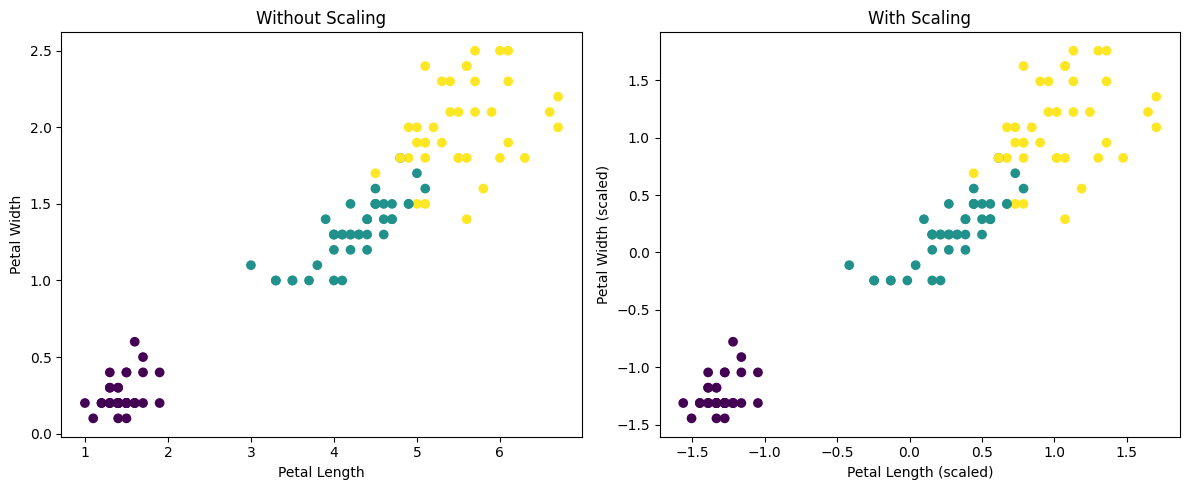

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# WITHOUT scaling
ax[0].scatter(
    X_train[:,2],
    X_train[:,3],
    c=y_train
)

ax[0].set_title("Without Scaling")
ax[0].set_xlabel("Petal Length")
ax[0].set_ylabel("Petal Width")

# WITH scaling
ax[1].scatter(
    X_train_s[:,2],
    X_train_s[:,3],
    c=y_train
)

ax[1].set_title("With Scaling")
ax[1].set_xlabel("Petal Length (scaled)")
ax[1].set_ylabel("Petal Width (scaled)")

plt.tight_layout()
plt.show()

### Finding the best K:

K=  1  CV accuracy=0.942
K=  3  CV accuracy=0.950
K=  5  CV accuracy=0.925
K=  7  CV accuracy=0.942
K=  9  CV accuracy=0.942
K= 11  CV accuracy=0.950
K= 13  CV accuracy=0.950
K= 15  CV accuracy=0.950
K= 17  CV accuracy=0.933
K= 19  CV accuracy=0.917
K= 21  CV accuracy=0.917


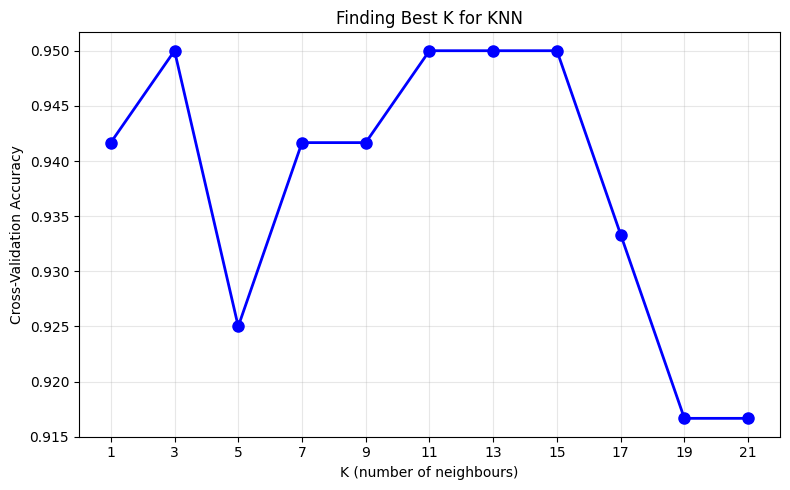


Best K = 3 with accuracy = 0.950


In [56]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# K too small = overfits (memorises single points)
# K too large = underfits (too many voters, loses detail)
# Best K = try odd numbers 1 to 21

## there are 3 methods
# 1) square_root of n 
# 2) get the odd n
# 3) cross value, check for all k and choose the best one


k_values   = list(range(1, 22, 2))   # 1,3,5,7,...,21 (odd only)
cv_scores  = []


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_s, y_train,
                              cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"K={k:3}  CV accuracy={scores.mean():.3f}")

# Plot K vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, 'b-o', linewidth=2, markersize=8)
plt.xlabel('K (number of neighbours)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Finding Best K for KNN')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"\nBest K = {best_k} with accuracy = {max(cv_scores):.3f}")

### loan approvals with both models

In [83]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# prepare dataset
np.random.seed(42) ## this will make same result after each iteration
n = 600 ## total numbers of emp

df = pd.DataFrame(
    {
        "name":[f"name_{i}" for i in np.random.randint(1,n,n)],
        "age":np.random.randint(21,35,n),
        "salary":np.random.randint(2000,35000,n),
        "credit_score":np.random.randint(100,900,n),
        'loan_amount'    : np.random.randint(10000, 500000, n),
        'emp_years'      : np.random.randint(0, 25, n),
        'debt_ratio'     : np.random.uniform(0, 0.9, n),
        'missed_payments': np.random.randint(0, 10, n),
    }
)

# Approval rules
df['approved'] = (
    (df['credit_score']    > 650) &
    (df['salary']          > 15000) &
    (df['debt_ratio']      < 0.5) &
    (df['missed_payments'] < 3)
).astype(int)

In [84]:
df

,name,age,salary,credit_score,loan_amount,emp_years,debt_ratio,missed_payments,approved
0,name_103,21,28399,553,25997,22,0.757867,9,0
1,name_436,25,21846,581,351895,22,0.218008,8,0
2,name_271,34,17708,693,108605,2,0.430434,3,0
3,name_107,29,12998,496,427127,3,0.130677,5,0
4,name_72,34,32678,378,327677,24,0.639099,6,0
...,...,...,...,...,...,...,...,...,...
595,name_437,22,27923,332,114648,15,0.481523,2,0
596,name_23,32,31165,629,48547,1,0.129949,1,0
597,name_565,21,3667,248,38795,7,0.705589,8,0
598,name_458,27,28213,496,196368,16,0.377451,0,0


In [85]:
print("Approval rate",df.approved.mean())

Approval rate 0.03


In [87]:
features = ['credit_score', "debt_ratio", "salary", "missed_payments", "loan_amount", "age", "emp_years"]
X = df[features]

In [88]:
y=df['approved']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

=== Decision Tree ===
              precision    recall  f1-score   support

    Rejected       0.97      0.98      0.97       116
    Approved       0.00      0.00      0.00         4

    accuracy                           0.95       120
   macro avg       0.48      0.49      0.49       120
weighted avg       0.93      0.95      0.94       120

=== KNN ===
              precision    recall  f1-score   support

    Rejected       0.97      1.00      0.98       116
    Approved       0.00      0.00      0.00         4

    accuracy                           0.97       120
   macro avg       0.48      0.50      0.49       120
weighted avg       0.93      0.97      0.95       120



D:\Abhi\myAIJourney\installation\envs\ai-engineer\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Abhi\myAIJourney\installation\envs\ai-engineer\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Abhi\myAIJourney\installation\envs\ai-engineer\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

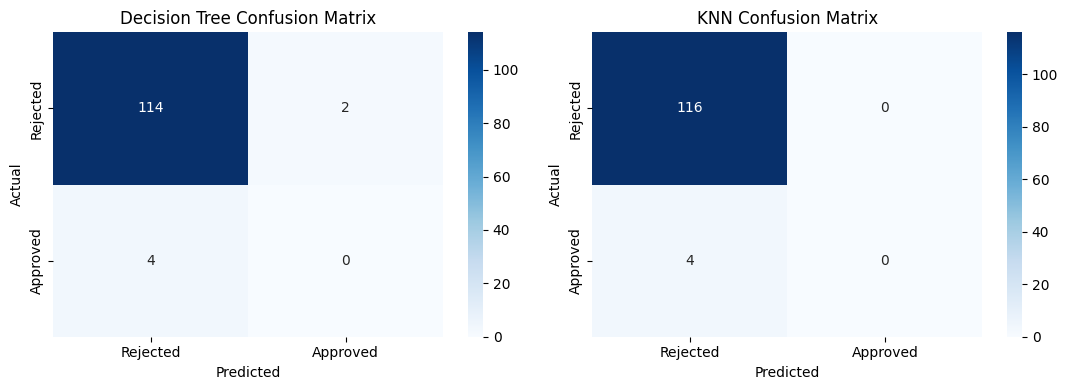

In [93]:
# Scale for KNN
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train both models
dt  = DecisionTreeClassifier(max_depth=6, random_state=42)
knn = KNeighborsClassifier(n_neighbors=7)

dt.fit(X_train, y_train)
knn.fit(X_train_s, y_train)

# Compare
print("=== Decision Tree ===")
print(classification_report(y_test, dt.predict(X_test),
      target_names=['Rejected','Approved']))

print("=== KNN ===")
print(classification_report(y_test, knn.predict(X_test_s),
      target_names=['Rejected','Approved']))

# Side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, preds) in zip(axes, [
    ('Decision Tree', dt.predict(X_test)),
    ('KNN',           knn.predict(X_test_s))
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected','Approved'],
                yticklabels=['Rejected','Approved'])
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()